# Quantify infrastructure burden

In [ ]:
# import all packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# import plotly.express as px
# import plotly.express as px
# import plotly.graph_objects as go
# from sklearn.preprocessing import StandardScaler
# from sklearn.preprocessing import MinMaxScaler

In [156]:
from scripts.plots_stats.get_df_ssp import get_df_ssp
df_ssp = get_df_ssp()
df = df_ssp.copy()
print(df.shape, df_ssp.shape)

(30544, 23) (30544, 23) (30544, 23) (30498, 23) (30498, 23) (30498, 23)
(30498, 41) (30544, 41)
Total number of cities 30498
(30498, 163) (30498, 163)


In [ ]:
(df[['volume_m3_perCap_2050_min', 'volume_m3_perCap_2050_mean', 'volume_m3_perCap_2050_max', 'volume_m3_perCap_2100_min', 'volume_m3_perCap_2100_mean', 'volume_m3_perCap_2100_max',
    'length_m_perCap_2050_min', 'length_m_perCap_2050_mean', 'length_m_perCap_2050_max','length_m_perCap_2100_min', 'length_m_perCap_2100_mean', 'length_m_perCap_2100_max']].sum()/1000000).round(3)

volume_m3_perCap_2050_min     28.094
volume_m3_perCap_2050_mean    28.227
volume_m3_perCap_2050_max     28.366
volume_m3_perCap_2100_min     32.424
volume_m3_perCap_2100_mean    32.644
volume_m3_perCap_2100_max     32.882
length_m_perCap_2050_min       1.650
length_m_perCap_2050_mean      1.650
length_m_perCap_2050_max       1.650
length_m_perCap_2100_min       1.961
length_m_perCap_2100_mean      1.962
length_m_perCap_2100_max       1.963
dtype: float64

In [159]:
df[['RBUV_Burden_2050_min','RBUV_Burden_2050','RBUV_Burden_2050_max', 'RBUV_Burden_2100_min', 'RBUV_Burden_2100', 'RBUV_Burden_2100_max']].apply(pd.Series.value_counts)

,RBUV_Burden_2050_min,RBUV_Burden_2050,RBUV_Burden_2050_max,RBUV_Burden_2100_min,RBUV_Burden_2100,RBUV_Burden_2100_max
decreasingBurden,16110,15974,15518,11525,11173,10324
increasingBurden,14378,14514,14970,18971,19323,20172
noChange,10,10,10,2,2,2


In [160]:
(df[['RBUV_Burden_2050_min','RBUV_Burden_2050','RBUV_Burden_2050_max', 'RBUV_Burden_2100_min', 'RBUV_Burden_2100', 'RBUV_Burden_2100_max']].apply(pd.Series.value_counts)*100/30498).round()

,RBUV_Burden_2050_min,RBUV_Burden_2050,RBUV_Burden_2050_max,RBUV_Burden_2100_min,RBUV_Burden_2100,RBUV_Burden_2100_max
decreasingBurden,53.0,52.0,51.0,38.0,37.0,34.0
increasingBurden,47.0,48.0,49.0,62.0,63.0,66.0
noChange,0.0,0.0,0.0,0.0,0.0,0.0


In [161]:
df[['RL_Burden_2050_min','RL_Burden_2050','RL_Burden_2050_max', 'RL_Burden_2100_min', 'RL_Burden_2100', 'RL_Burden_2100_max']].apply(pd.Series.value_counts)

,RL_Burden_2050_min,RL_Burden_2050,RL_Burden_2050_max,RL_Burden_2100_min,RL_Burden_2100,RL_Burden_2100_max
decreasingBurden,16735,16731,16727,12724,12718,12705
increasingBurden,13753,13757,13761,17772,17778,17791
noChange,10,10,10,2,2,2


In [162]:
(df[['RL_Burden_2050_min','RL_Burden_2050','RL_Burden_2050_max', 'RL_Burden_2100_min', 'RL_Burden_2100', 'RL_Burden_2100_max']].apply(pd.Series.value_counts)*100/30498).round()

,RL_Burden_2050_min,RL_Burden_2050,RL_Burden_2050_max,RL_Burden_2100_min,RL_Burden_2100,RL_Burden_2100_max
decreasingBurden,55.0,55.0,55.0,42.0,42.0,42.0
increasingBurden,45.0,45.0,45.0,58.0,58.0,58.0
noChange,0.0,0.0,0.0,0.0,0.0,0.0


### Constandtly decreasing burden

In [163]:
condition = (df_ssp['volume_m3_perCap_2020_mean'] > df_ssp['volume_m3_perCap_2030_mean']) & (df_ssp['volume_m3_perCap_2030_mean'] > df_ssp['volume_m3_perCap_2040_mean']) & \
            (df_ssp['volume_m3_perCap_2040_mean'] > df_ssp['volume_m3_perCap_2050_mean']) & (df_ssp['volume_m3_perCap_2050_mean'] > df_ssp['volume_m3_perCap_2060_mean']) & \
            (df_ssp['volume_m3_perCap_2060_mean'] > df_ssp['volume_m3_perCap_2070_mean']) & (df_ssp['volume_m3_perCap_2070_mean'] > df_ssp['volume_m3_perCap_2080_mean']) & \
            (df_ssp['volume_m3_perCap_2080_mean'] > df_ssp['volume_m3_perCap_2090_mean']) & (df_ssp['volume_m3_perCap_2090_mean'] > df_ssp['volume_m3_perCap_2100_mean'])
print(f"cities that face constantly decreasing burden for RBUV {np.round(df_ssp[condition].shape[0]*100/df_ssp.shape[0], 0)}")

condition = (df_ssp['length_m_perCap_2020_mean'] > df_ssp['length_m_perCap_2030_mean']) & (df_ssp['length_m_perCap_2030_mean'] > df_ssp['length_m_perCap_2040_mean']) & \
            (df_ssp['length_m_perCap_2040_mean'] > df_ssp['length_m_perCap_2050_mean']) & (df_ssp['length_m_perCap_2050_mean'] > df_ssp['length_m_perCap_2060_mean']) & \
            (df_ssp['length_m_perCap_2060_mean'] > df_ssp['length_m_perCap_2070_mean']) & (df_ssp['length_m_perCap_2070_mean'] > df_ssp['length_m_perCap_2080_mean']) & \
            (df_ssp['length_m_perCap_2080_mean'] > df_ssp['length_m_perCap_2090_mean']) & (df_ssp['length_m_perCap_2090_mean'] > df_ssp['length_m_perCap_2100_mean'])
print(f"cities that face constantly decreasing burden for RL {np.round(df_ssp[condition].shape[0]*100/df_ssp.shape[0], 0)}")

cities that face constantly decreasing burden for RBUV 25.0
cities that face constantly decreasing burden for RL 25.0


In [164]:
df_ssp.filter(regex='volume').columns
print("Percent cities with decreasing built volumes")

column_nmaes1 = ['volume_m3_perCap_2020_mean','volume_m3_perCap_2030_mean', 'volume_m3_perCap_2040_mean','volume_m3_perCap_2050_mean', 'volume_m3_perCap_2060_mean',
                'volume_m3_perCap_2070_mean', 'volume_m3_perCap_2080_mean', 'volume_m3_perCap_2090_mean']
column_nmaes2 = ['volume_m3_perCap_2030_mean', 'volume_m3_perCap_2040_mean','volume_m3_perCap_2050_mean', 'volume_m3_perCap_2060_mean',
                'volume_m3_perCap_2070_mean', 'volume_m3_perCap_2080_mean', 'volume_m3_perCap_2090_mean', 'volume_m3_perCap_2100_mean']
for col1, col2 in zip(column_nmaes1, column_nmaes2):
    print(np.round(df_ssp[df_ssp[col2] < df_ssp[col1]].shape[0]*100/df_ssp.shape[0],2))

print("Percent cities with decreasing roadways")

column_nmaes1 = ['length_m_perCap_2020_mean','length_m_perCap_2030_mean', 'length_m_perCap_2040_mean','length_m_perCap_2050_mean', 
                 'length_m_perCap_2060_mean','length_m_perCap_2070_mean', 'length_m_perCap_2080_mean', 'length_m_perCap_2090_mean']
column_nmaes2 = ['length_m_perCap_2030_mean', 'length_m_perCap_2040_mean','length_m_perCap_2050_mean', 'length_m_perCap_2060_mean',
                 'length_m_perCap_2070_mean', 'length_m_perCap_2080_mean', 'length_m_perCap_2090_mean', 'length_m_perCap_2100_mean']
for col1, col2 in zip(column_nmaes1, column_nmaes2):
    print(np.round(df_ssp[df_ssp[col2] < df_ssp[col1]].shape[0]*100/df_ssp.shape[0],2))

Percent cities with decreasing built volumes
65.71
52.52
47.39
49.9
48.29
42.42
34.14
27.15
Percent cities with decreasing roadways
65.79
52.77
47.52
50.08
48.51
42.49
34.29
27.29


### Increasing burden ====== For all city types with an increasing burden

In [165]:
print("For all city types with an increasing burden====")
print("=====================================================")
print("Total RBUV in 2020: ======")
Total_RBUV_2020 = np.sum(df[(df['RBUV_Burden_2050'] == 'increasingBurden')]['volume_m3_perCap_2020_mean'] * df[(df['RBUV_Burden_2050'] == 'increasingBurden')]['CensusPop_20'])
print(Total_RBUV_2020)
print("Total RBUV in 2050: ======")
Total_RBUV_2050 = np.sum(df[(df['RBUV_Burden_2050'] == 'increasingBurden')]['volume_m3_perCap_2050_mean'] * df[(df['RBUV_Burden_2050'] == 'increasingBurden')]['ssp22050'].round(0))
print(Total_RBUV_2050)
print(f"Change in RBUV from 2020 to 2050, {Total_RBUV_2050 -Total_RBUV_2020}")

print(f"Total housing units in 2020, {np.round((Total_RBUV_2020)/ (187*4.6))}")
print(f"Total housing units in 2050, {np.round((Total_RBUV_2050)/ (187*4.6))}")
print(f"Added housing units, {np.round((Total_RBUV_2050 -Total_RBUV_2020)/ (187*4.6))}")
print('\n')

print("Total RBUV in 2050: ======")
Total_RBUV_2050 = np.sum(df[(df['RBUV_Burden_2100'] == 'increasingBurden')]['volume_m3_perCap_2050_mean'] * df[(df['RBUV_Burden_2100'] == 'increasingBurden')]['ssp22050'].round(0))
print(Total_RBUV_2050)
print("Total RBUV in 2050: ======")
Total_RBUV_2100 = np.sum(df[(df['RBUV_Burden_2100'] == 'increasingBurden')]['volume_m3_perCap_2100_mean'] * df[(df['RBUV_Burden_2100'] == 'increasingBurden')]['ssp22100'].round(0))
print(Total_RBUV_2100)
print(f"Change in RBUV from 2050 to 2100, {Total_RBUV_2100 -Total_RBUV_2050}")

print(f"Total housing units in 2050, {np.round((Total_RBUV_2050)/ (187*4.6))}")
print(f"Total housing units in 2100, {np.round((Total_RBUV_2100)/ (187*4.6))}")
print(f"Added housing units, {np.round((Total_RBUV_2100 -Total_RBUV_2050)/ (187*4.6))}")

For all city types with an increasing burden====
Total RBUV in 2020: ======
25339958116.40392
Total RBUV in 2050: ======
25487248866.39361
Change in RBUV from 2020 to 2050, 147290749.98968887
Total housing units in 2020, 29458217.0
Total housing units in 2050, 29629445.0
Added housing units, 171228.0


Total RBUV in 2050: ======
64716173970.173515
Total RBUV in 2050: ======
66165840344.69636
Change in RBUV from 2050 to 2100, 1449666374.5228424
Total housing units in 2050, 75233869.0
Total housing units in 2100, 76919135.0
Added housing units, 1685267.0


### Excluding cities over 10000 per cap volume ==== For cities with an increasing burden

### Abandoned units in single family unit equivalent

### RBUV equivalent to single family unit

In [166]:
'''NOTES
Ref. https://www.ahs.com/home-matters/real-estate/the-2022-american-home-size-index/
Median single family housing size = 2,014 SQ. FT.
The median size of a completed single-family home in the United States was 2,233 square feet in 2023, according to the U.S. Census Bureau

Ref.https://www.statista.com/statistics/183635/number-of-households-in-the-us/#:~:text=Household%20changes,to%202.51%20people%20per%20household.
In 2022, the average household size was 2.6 people, calculated by dividing the total household population by the total number of households

Considering 15 ft floor to ceiling height, 2233*15 = 33495 CU Ft = 948.5 cubic meter
Per capita volume = 948.5/2.51 =  378 cubic meter

'''
# [Area (sft) * floor height (ft) / Househols size] * [cubic ft t cubic meter conversion factor]
per_cap_sf_HU_size = np.round(2014*15/2.51 *(0.0283168),0)
print(per_cap_sf_HU_size)

341.0


### Consider 2% min and 8% max decadal demolition 

In [167]:
# print("For all city types====")
# print("=====================================================")

def added_units_in_SF_eq(df, vol_columnt0, vol_columnt1, vol_columnt2, burden_colt1, burden_colt2):

    print("Total RBUV in 2020: ======")
    df0 = df[df[vol_columnt0] < 10000]

    Total_RBUV_2020 = np.sum(df0[(df0[burden_colt1] == 'increasingBurden')][vol_columnt0] * df0[(df0[burden_colt1] == 'increasingBurden')]['CensusPop_20'])
    print(Total_RBUV_2020)
    print("Total RBUV in 2050: ======")
    Total_RBUV_2050 = np.sum(df0[(df0[burden_colt1] == 'increasingBurden')][vol_columnt1] * df0[(df0[burden_colt1] == 'increasingBurden')]['ssp22050'].round(0))
    print(Total_RBUV_2050)
    print(f"Change in RBUV from 2020 to 2050, {Total_RBUV_2050 -Total_RBUV_2020}")

    print(f"Total housing units in 2020, {np.round((Total_RBUV_2020)/ (187*4.6))}")
    print(f"Total housing units in 2050, {np.round((Total_RBUV_2050)/ (187*4.6))}")
    added_units_2020_2050 = np.round((Total_RBUV_2050 -Total_RBUV_2020)/ (187*4.6))
    print(f"Added housing units, {added_units_2020_2050}")
    print('\n')

    print("Total RBUV in 2050: ======")
    Total_RBUV_2050 = np.sum(df0[(df0[burden_colt2] == 'increasingBurden')][vol_columnt1] * df0[(df0[burden_colt2] == 'increasingBurden')]['ssp22050'].round(0))
    print(Total_RBUV_2050)
    print("Total RBUV in 2050: ======")
    Total_RBUV_2100 = np.sum(df0[(df0[burden_colt2] == 'increasingBurden')][vol_columnt2] * df0[(df0[burden_colt2] == 'increasingBurden')]['ssp22100'].round(0))
    print(Total_RBUV_2100)
    print(f"Change in RBUV from 2050 to 2100, {Total_RBUV_2100 -Total_RBUV_2050}")

    print(f"Total housing units in 2050, {np.round((Total_RBUV_2050)/ (187*4.6))}")
    print(f"Total housing units in 2100, {np.round((Total_RBUV_2100)/ (187*4.6))}")
    added_units_2050_2100 = np.round((Total_RBUV_2100 -Total_RBUV_2050)/ (187*4.6))
    print(f"Added housing units, {added_units_2050_2100}")

    print("Remaining abandoned units after 2% and 8% decadal demolition in 2050")
    print(np.round(added_units_2020_2050* (1-0.02)**3), np.round(added_units_2020_2050*(1-0.08)**3))
    print("Remaining abandoned units after 2% and 8% decadal demolition in 2100")
    print(np.round(added_units_2050_2100*(1-0.02)**5), np.round(added_units_2050_2100*(1-0.08)**5))
    print("====================================================================================\n")

In [168]:
print("=============== For mean =======================\n")

added_units_in_SF_eq(df, 'volume_m3_perCap_2020_mean',  'volume_m3_perCap_2050_mean', 'volume_m3_perCap_2100_mean', 'RBUV_Burden_2050', 'RBUV_Burden_2100')

print("=============== For minimum =======================\n")

added_units_in_SF_eq(df, 'volume_m3_perCap_2020_min',  'volume_m3_perCap_2050_min', 'volume_m3_perCap_2100_min', 'RBUV_Burden_2050_min', 'RBUV_Burden_2100_min')

print("=============== For maximum =======================\n")

added_units_in_SF_eq(df, 'volume_m3_perCap_2020_max',  'volume_m3_perCap_2050_max', 'volume_m3_perCap_2100_max', 'RBUV_Burden_2050_max', 'RBUV_Burden_2100_max')

=============== For mean =======================

Total RBUV in 2020: ======
25320868192.517647
Total RBUV in 2050: ======
25468122067.095062
Change in RBUV from 2020 to 2050, 147253874.57741547
Total housing units in 2020, 29436024.0
Total housing units in 2050, 29607210.0
Added housing units, 171186.0


Total RBUV in 2050: ======
64682404328.72807
Total RBUV in 2050: ======
66131615189.05858
Change in RBUV from 2050 to 2100, 1449210860.3305054
Total housing units in 2050, 75194611.0
Total housing units in 2100, 76879348.0
Added housing units, 1684737.0
Remaining abandoned units after 2% and 8% decadal demolition in 2050
161119.0 133300.0
Remaining abandoned units after 2% and 8% decadal demolition in 2100
1522869.0 1110379.0

=============== For minimum =======================

Total RBUV in 2020: ======
23711223117.8
Total RBUV in 2050: ======
23803689560.637592
Change in RBUV from 2020 to 2050, 92466442.83759308
Total housing units in 2020, 27564779.0
Total housing units in 2050, 2

In [ ]:
'''
min
Remaining abandoned units after 2% and 8% decadal demolition in 2050
101733.0 84168.0
Remaining abandoned units after 2% and 8% decadal demolition in 2100
705199.0 514186.0
mean
Remaining abandoned units after 2% and 8% decadal demolition in 2050
159883.0 132278.0
Remaining abandoned units after 2% and 8% decadal demolition in 2100
1569083.0 1144075.0
max
Remaining abandoned units after 2% and 8% decadal demolition in 2050
11548760.0 9554778.0
Remaining abandoned units after 2% and 8% decadal demolition in 2100
14475361.0 10554512.0
'''

'\nmin\nRemaining abandoned units after 2% and 8% decadal demolition in 2050\n101733.0 84168.0\nRemaining abandoned units after 2% and 8% decadal demolition in 2100\n705199.0 514186.0\nmean\nRemaining abandoned units after 2% and 8% decadal demolition in 2050\n159883.0 132278.0\nRemaining abandoned units after 2% and 8% decadal demolition in 2100\n1569083.0 1144075.0\n\nRemaining abandoned units after 2% and 8% decadal demolition in 2050\n161119.0 133300.0\nRemaining abandoned units after 2% and 8% decadal demolition in 2100\n1522869.0 1110379.0\nmax\nRemaining abandoned units after 2% and 8% decadal demolition in 2050\n11548760.0 9554778.0\nRemaining abandoned units after 2% and 8% decadal demolition in 2100\n14475361.0 10554512.0\n\nRemaining abandoned units after 2% and 8% decadal demolition in 2050\n11705458.0 9684421.0\nRemaining abandoned units after 2% and 8% decadal demolition in 2100\n14391507.0 10493371.0\n'

In [181]:
df[['volume_m3_perCap_2100_min','volume_m3_perCap_2100_mean', 'volume_m3_perCap_2100_max']].sum()

volume_m3_perCap_2100_min     3.242379e+07
volume_m3_perCap_2100_mean    3.264399e+07
volume_m3_perCap_2100_max     3.288238e+07
dtype: float64

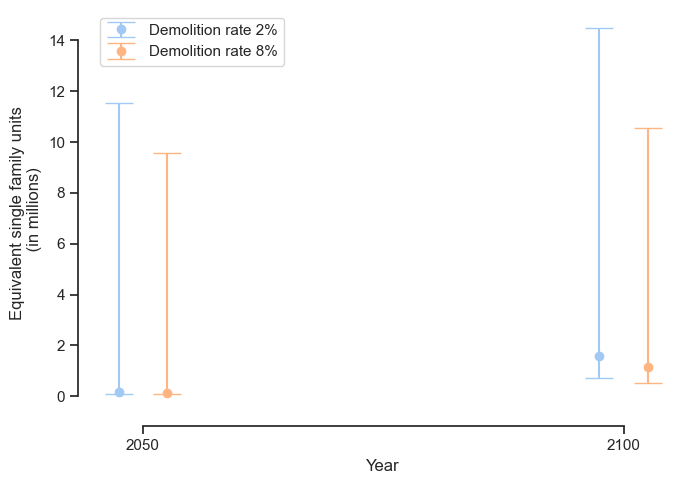

In [171]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Seaborn theme
sns.set_theme(style="ticks", palette="pastel")

# Sample Data
grouped = pd.DataFrame(
    {'year': ['2050', '2100','2050', '2100'],
     'min': [101733,705199, 84168, 514186],
     'mean': [159883, 1569083, 132278, 1144075], 
     'max': [11548760, 14475361, 9554778, 10554512],
     'Demolition rate':['2%', '2%', '8%', '8%']
    })

grouped[['min', 'mean', 'max']] = grouped[['min', 'mean', 'max']].div(1000000)
grouped['err_lower'] = grouped['mean'] - grouped['min']
grouped['err_upper'] = grouped['max'] - grouped['mean']
grouped
# Plot setup
fig, ax = plt.subplots(figsize=(7, 5))

# Create x locations for bars
years = sorted(grouped['year'].unique())
scenarios = sorted(grouped['Demolition rate'].unique())
bar_width = 0.1
x = np.arange(len(years))

# Plot each scenario with an offset
for i, scenario in enumerate(scenarios):
    subset = grouped[grouped['Demolition rate'] == scenario]
    offset = (i - len(scenarios)/2) * bar_width + bar_width/2
    x_pos = x + offset

    ax.errorbar(
        x_pos,
        subset['mean'],
        yerr=[subset['err_lower'], subset['err_upper']],
        fmt='o',
        capsize=10,
        label=f'Demolition rate {scenario}'
    )

# Clean styling
sns.despine(offset=10, trim=True)
# Axis setup
ax.set_xticks(x)
ax.set_xticklabels(years)
# ax.set_title('Cities with an increasing burden \n with sampled $beta$', fontsize=12)
ax.set_xlabel('Year')
ax.set_ylabel('Equivalent single family units \n (in millions)')
ax.legend()

plt.tight_layout()
plt.show()

In [172]:
# print("Only for suburban cities====")
# print("=============================")
# df0 = df[df['volume_m3_perCap_2020_mean'] < 10000]
# print("Total RBUV in 2020: ======")
# condition = (df0['RBUV_Burden_2050'] == 'increasingBurden') & (df0['city type'] == 'suburban')
# Total_RBUV_2020 = np.sum(df0[condition]['volume_m3_perCap_2020_mean'] * df0[condition]['CensusPop_20'])
# print(Total_RBUV_2020)
# print("Total RBUV in 2050: ======")
# Total_RBUV_2050 = np.sum(df0[condition]['volume_m3_perCap_2050_mean'] * df0[condition]['ssp22050'].round(0))
# print(Total_RBUV_2050)
# print(f"Change in RBUV from 2020 to 2050, {Total_RBUV_2050 -Total_RBUV_2020}")

# print(f"Total housing units in 2020, {np.round((Total_RBUV_2020)/ (187*4.6))}")
# print(f"Total housing units in 2050, {np.round((Total_RBUV_2050)/ (187*4.6))}")
# added_units_2020_2050 = np.round((Total_RBUV_2050 -Total_RBUV_2020)/ (187*4.6))
# print(f"Added housing units, {added_units_2020_2050}")
# print('\n')

# condition = (df0['RBUV_Burden_2100'] == 'increasingBurden') & (df0['city type'] == 'suburban')
# print("Total RBUV in 2050: ======")
# Total_RBUV_2050 = np.sum(df0[condition]['volume_m3_perCap_2050_mean'] * df0[condition]['ssp22050'].round(0))
# print(Total_RBUV_2050)
# print("Total RBUV in 2050: ======")
# Total_RBUV_2100 = np.sum(df0[condition]['volume_m3_perCap_2100_mean'] * df0[condition]['ssp22100'].round(0))
# print(Total_RBUV_2100)
# print(f"Change in RBUV from 2050 to 2100, {Total_RBUV_2100 -Total_RBUV_2050}")

# print(f"Total housing units in 2050, {np.round((Total_RBUV_2050)/ (187*4.6))}")
# print(f"Total housing units in 2100, {np.round((Total_RBUV_2100)/ (187*4.6))}")
# added_units_2050_2100 = np.round((Total_RBUV_2100 -Total_RBUV_2050)/ (187*4.6))
# print(f"Added housing units, {added_units_2050_2100}")

# print("Remaining abandoned units after 2% and 8% decadal demolition in 2050")
# print(np.round(added_units_2020_2050* (1-0.02)**3), np.round(added_units_2020_2050*(1-0.08)**3))
# print("Remaining abandoned units after 2% and 8% decadal demolition in 2100")
# print(np.round(added_units_2050_2100*(1-0.02)**5), np.round(added_units_2050_2100*(1-0.08)**5))

### Consider 2% min and 8% max decadal demolition 

In [173]:
burden_column_list = ['RBUV_Burden_2030_in','RBUV_Burden_2040_in','RBUV_Burden_2050_in','RBUV_Burden_2060_in','RBUV_Burden_2070_in','RBUV_Burden_2080_in', 'RBUV_Burden_2090_in','RBUV_Burden_2100_in']
pop_column_list = ['CensusPop_20','ssp22030', 'ssp22040','ssp22050','ssp22060', 'ssp22070','ssp22080','ssp22090','ssp22100']
infra_column_list = ['volume_m3_perCap_2020_mean','volume_m3_perCap_2030_mean', 'volume_m3_perCap_2040_mean','volume_m3_perCap_2050_mean', 'volume_m3_perCap_2060_mean',
                     'volume_m3_perCap_2070_mean', 'volume_m3_perCap_2080_mean','volume_m3_perCap_2090_mean', 'volume_m3_perCap_2100_mean']

total_with_2 = 0
total_with_8 = 0
for p1, p2, v1, v2, b in zip(pop_column_list[:-1],pop_column_list[1:], infra_column_list[:-1], infra_column_list[1:], burden_column_list):
    print(b)
#     print(p1, p2, v1, v2)
    print("==========================")
    condition = (df0[b] == 'increasingBurden') 
    Total_RBUV_t1 = np.sum(df0[condition][v1] * df0[condition][p1])
    # print(Total_RBUV_t1)
    Total_RBUV_t2 = np.sum(df0[condition][v2] * df0[condition][p2])
    # print(Total_RBUV_t2)
    print(f"Change in RBUV from t1 to t2 in cubic meter, {Total_RBUV_t2 -Total_RBUV_t1}")

    # print(f"Total housing units in 2020, {np.round((Total_RBUV_t1)/ (187*4.6))}")
    # print(f"Total housing units in 2050, {np.round((Total_RBUV_t2)/ (187*4.6))}")
    print(f"Abandoned housing units, {np.round((Total_RBUV_t2 -Total_RBUV_t1)/ (187*4.6))}")
    print("Considering 2% demilition per decade:")
    abandoned_with_2 = np.round(0.98*(Total_RBUV_t2 -Total_RBUV_t1)/ (187*4.6))
    print(f"Abandoned housing units, {abandoned_with_2}")
    total_with_2 += abandoned_with_2
    print('Total abandoned with 2% demolition=== ', total_with_2)
    print("Considering 8% demilition per decade:")
    abandoned_with_8 = np.round(0.92*(Total_RBUV_t2 -Total_RBUV_t1)/ (187*4.6))
    print(f"Abandoned housing units, {abandoned_with_8}")
    total_with_8 += abandoned_with_8
    print('Total abandoned with 8% demolition=== ', total_with_8)
    # print(f"Abandoned housing units, {np.round(0.92*(Total_RBUV_t2 -Total_RBUV_t1)/ (187*4.6))}")
    print('\n')
    # print(p1, p2, v1, v2)

RBUV_Burden_2030_in
Change in RBUV from t1 to t2 in cubic meter, 417270.9204120636
Abandoned housing units, 485.0
Considering 2% demilition per decade:
Abandoned housing units, 475.0
Total abandoned with 2% demolition===  475.0
Considering 8% demilition per decade:
Abandoned housing units, 446.0
Total abandoned with 8% demolition===  446.0


RBUV_Burden_2040_in
Change in RBUV from t1 to t2 in cubic meter, 420120.9855918884
Abandoned housing units, 488.0
Considering 2% demilition per decade:
Abandoned housing units, 479.0
Total abandoned with 2% demolition===  954.0
Considering 8% demilition per decade:
Abandoned housing units, 449.0
Total abandoned with 8% demolition===  895.0


RBUV_Burden_2050_in
Change in RBUV from t1 to t2 in cubic meter, 285510.2548522949
Abandoned housing units, 332.0
Considering 2% demilition per decade:
Abandoned housing units, 325.0
Total abandoned with 2% demolition===  1279.0
Considering 8% demilition per decade:
Abandoned housing units, 305.0
Total abandone

In [174]:
# As of April 2024, the total number of housing units in the United States was 146,640,000.
1755973*100/146640000, 1648465.0*100/146640000, 1755973-1648465, 14475361*100/146640000, 101733*100/146640000, 159883*100/146640000

(1.1974720403709764,
 1.1241578014184397,
 107508,
 9.87135911074741,
 0.06937602291325695,
 0.1090309601745772)

### Roads equivalent

In [175]:
print("For all city types with increasing burden====")
print("=============================")
print("Total RL in 2020: ======")
Total_RL_2020 = np.sum(df[(df['RL_Burden_2050'] == 'increasingBurden')]['length_m_perCap_2020_mean'] * df[(df['RL_Burden_2050'] == 'increasingBurden')]['CensusPop_20'])
print(Total_RL_2020)
print("Total RL in 2050: ======")
Total_RL_2050 = np.sum(df[(df['RL_Burden_2050'] == 'increasingBurden')]['length_m_perCap_2050_mean'] * df[(df['RL_Burden_2050'] == 'increasingBurden')]['ssp22050'].round(0))
print(Total_RL_2050)
print(f"Change in RL from 2020 to 2050, {Total_RL_2050 -Total_RL_2020}")
print(f"Added total km, {np.round((Total_RL_2050 -Total_RL_2020)/1000)}")
print('\n')
print("Total RL in 2050: ======")
Total_RL_2050 = np.sum(df[(df['RL_Burden_2100'] == 'increasingBurden')]['length_m_perCap_2050_mean'] * df[(df['RL_Burden_2100'] == 'increasingBurden')]['ssp22050'].round(0))
print(Total_RL_2050)
print("Total RL in 2100: ======")
Total_RL_2100 = np.sum(df[(df['RL_Burden_2100'] == 'increasingBurden')]['length_m_perCap_2100_mean'] * df[(df['RL_Burden_2100'] == 'increasingBurden')]['ssp22100'].round(0))
print(Total_RL_2100)
print(f"Change in RL from 2050 to 2100, {Total_RL_2100 -Total_RL_2050}")
print(f"Added total km, {np.round((Total_RL_2100 -Total_RL_2050)/1000)}")

For all city types with increasing burden====
Total RL in 2020: ======
613022119.4052305
Total RL in 2050: ======
613134967.1155162
Change in RL from 2020 to 2050, 112847.7102856636
Added total km, 113.0


Total RL in 2050: ======
975323278.2010761
Total RL in 2100: ======
975584791.8130349
Change in RL from 2050 to 2100, 261513.61195874214
Added total km, 262.0


In [176]:
print("For all city types with increasing burden====")
print("=============================")
print("Total RL in 2020: ======")
Total_RL_2020 = np.sum(df[(df['RL_Burden_2050_min'] == 'increasingBurden')]['length_m_perCap_2020_min'] * df[(df['RL_Burden_2050_min'] == 'increasingBurden')]['CensusPop_20'])
print(Total_RL_2020)
print("Total RL in 2050: ======")
Total_RL_2050 = np.sum(df[(df['RL_Burden_2050_min'] == 'increasingBurden')]['length_m_perCap_2050_min'] * df[(df['RL_Burden_2050_min'] == 'increasingBurden')]['ssp22050'].round(0))
print(Total_RL_2050)
print(f"Change in RL from 2020 to 2050, {Total_RL_2050 -Total_RL_2020}")
print(f"Added total km, {np.round((Total_RL_2050 -Total_RL_2020)/1000)}")
print('\n')
print("Total RL in 2050: ======")
Total_RL_2050 = np.sum(df[(df['RL_Burden_2100_min'] == 'increasingBurden')]['length_m_perCap_2050_min'] * df[(df['RL_Burden_2100_min'] == 'increasingBurden')]['ssp22050'].round(0))
print(Total_RL_2050)
print("Total RL in 2100: ======")
Total_RL_2100 = np.sum(df[(df['RL_Burden_2100_min'] == 'increasingBurden')]['length_m_perCap_2100_min'] * df[(df['RL_Burden_2100_min'] == 'increasingBurden')]['ssp22100'].round(0))
print(Total_RL_2100)
print(f"Change in RL from 2050 to 2100, {Total_RL_2100 -Total_RL_2050}")
print(f"Added total km, {np.round((Total_RL_2100 -Total_RL_2050)/1000)}")

For all city types with increasing burden====
Total RL in 2020: ======
612492186.9608442
Total RL in 2050: ======


612590745.2492195
Change in RL from 2020 to 2050, 98558.28837537766
Added total km, 99.0


Total RL in 2050: ======
971227701.6446493
Total RL in 2100: ======
971449454.4476514
Change in RL from 2050 to 2100, 221752.80300211906
Added total km, 222.0


In [177]:
print("For all city types with increasing burden====")
print("=============================")
print("Total RL in 2020: ======")
Total_RL_2020 = np.sum(df[(df['RL_Burden_2050_max'] == 'increasingBurden')]['length_m_perCap_2020_max'] * df[(df['RL_Burden_2050_max'] == 'increasingBurden')]['CensusPop_20'])
print(Total_RL_2020)
print("Total RL in 2050: ======")
Total_RL_2050 = np.sum(df[(df['RL_Burden_2050_max'] == 'increasingBurden')]['length_m_perCap_2050_max'] * df[(df['RL_Burden_2050_max'] == 'increasingBurden')]['ssp22050'].round(0))
print(Total_RL_2050)
print(f"Change in RL from 2020 to 2050, {Total_RL_2050 -Total_RL_2020}")
print(f"Added total km, {np.round((Total_RL_2050 -Total_RL_2020)/1000)}")
print('\n')
print("Total RL in 2050: ======")
Total_RL_2050 = np.sum(df[(df['RL_Burden_2100_max'] == 'increasingBurden')]['length_m_perCap_2050_max'] * df[(df['RL_Burden_2100_max'] == 'increasingBurden')]['ssp22050'].round(0))
print(Total_RL_2050)
print("Total RL in 2100: ======")
Total_RL_2100 = np.sum(df[(df['RL_Burden_2100_max'] == 'increasingBurden')]['length_m_perCap_2100_max'] * df[(df['RL_Burden_2100_max'] == 'increasingBurden')]['ssp22100'].round(0))
print(Total_RL_2100)
print(f"Change in RL from 2050 to 2100, {Total_RL_2100 -Total_RL_2050}")
print(f"Added total km, {np.round((Total_RL_2100 -Total_RL_2050)/1000)}")

For all city types with increasing burden====
Total RL in 2020: ======
615180757.0023351
Total RL in 2050: ======
615333867.9347628
Change in RL from 2020 to 2050, 153110.93242776394
Added total km, 153.0


Total RL in 2050: ======
976547160.454057
Total RL in 2100: ======
976857404.3727609
Change in RL from 2050 to 2100, 310243.9187039137
Added total km, 310.0


In [178]:
print("For each city type with increasing burden====")
print("=============================")
city_type_name = ['urban', 'suburban', 'periurban', 'rural']
for city in city_type_name:
    print(f"city type ======= {city}")
    condition = (df['RL_Burden_2050'] == 'increasingBurden') & (df['city type'] == city)
    # print("Total RL in 2020: ======")
    Total_RL_2020 = np.sum(df[condition]['length_m_perCap_2020_mean'] * df[condition]['CensusPop_20'])
    # print(Total_RL_2020)
    # print("Total RL in 2050: ======")
    Total_RL_2050 = np.sum(df[condition]['length_m_perCap_2050_mean'] * df[condition]['ssp22050'].round(0))
    # print(Total_RL_2050)
    # print(f"Change in RL from 2020 to 2050, {Total_RL_2050 -Total_RL_2020}")
    print(f"Added roadway length from 2020-2050 in km, {np.round((Total_RL_2050 -Total_RL_2020)/1000)}")
    # print('\n')
    condition = (df['RL_Burden_2100'] == 'increasingBurden') & (df['city type'] == city)
    # print("Total RL in 2050: ======")
    Total_RL_2050 = np.sum(df[condition]['length_m_perCap_2050_mean'] * df[condition]['ssp22050'].round(0))
    # print(Total_RL_2050)
    # print("Total RL in 2100: ======")
    Total_RL_2100 = np.sum(df[condition]['length_m_perCap_2100_mean'] * df[condition]['ssp22100'].round(0))
    # print(Total_RL_2100)
    # print(f"Change in RL from 2050 to 2100, {Total_RL_2100 -Total_RL_2050}")
    print(f"Added roadway length from 2050-2100 in km, {np.round((Total_RL_2100 -Total_RL_2050)/1000)}")
    print('\n')

For each city type with increasing burden====
city type ======= urban
Added roadway length from 2020-2050 in km, 8.0
Added roadway length from 2050-2100 in km, 16.0


city type ======= suburban
Added roadway length from 2020-2050 in km, 69.0
Added roadway length from 2050-2100 in km, 187.0


city type ======= periurban
Added roadway length from 2020-2050 in km, 18.0
Added roadway length from 2050-2100 in km, 44.0


city type ======= rural
Added roadway length from 2020-2050 in km, 18.0
Added roadway length from 2050-2100 in km, 14.0




In [179]:
'''
mean
Change in RL from 2020 to 2050, Added total km, 112.0
Change in RL from 2050 to 2100, Added total km, 261.0
min
Change in RL from 2020 to 2050, Added total km, 99.0
Change in RL from 2050 to 2100, Added total km, 222.0
max
Change in RL from 2020 to 2050, Added total km, 153.0
Change in RL from 2050 to 2100, Added total km, 310.0

'''

'\nmean\nChange in RL from 2020 to 2050, Added total km, 112.0\nChange in RL from 2050 to 2100, Added total km, 261.0\nmin\nChange in RL from 2020 to 2050, Added total km, 99.0\nChange in RL from 2050 to 2100, Added total km, 222.0\nmax\nChange in RL from 2020 to 2050, Added total km, 153.0\nChange in RL from 2050 to 2100, Added total km, 310.0\n\n'

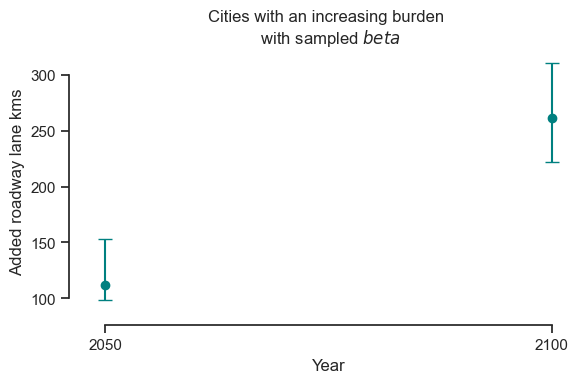

In [180]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Apply Seaborn theme
sns.set_theme(style="ticks", palette="pastel")

grouped = pd.DataFrame(
    {'year': ['2050', '2100'],
     'mean': [112, 261],
     'min': [99, 222], 
     'max': [153, 310]
    })

# Calculate error bars
grouped['err_lower'] = grouped['mean'] - grouped['min']
grouped['err_upper'] = grouped['max'] - grouped['mean']

# Plot
fig, ax = plt.subplots(figsize=(6, 4))

ax.errorbar(
    grouped['year'],
    grouped['mean'],
    yerr=[grouped['err_lower'], grouped['err_upper']],
    fmt='o',       # 'o' = just points, no line
    capsize=5,
    color='teal',
    # label='Min-Max range using beta sampled'
)

# Clean styling
sns.despine(offset=10, trim=True)
ax.set_title('Cities with an increasing burden \n with sampled $beta$', fontsize=12)
ax.set_xlabel('Year')
ax.set_ylabel('Added roadway lane kms')
# ax.legend()

plt.tight_layout()
plt.show()



In [ ]:
# def label_burden(row, col1, col2):
#     if np.round(row[col1], 2) < np.round(row[col2],2):
#         return 'increasingBurden'
#     elif np.round(row[col1],2) > np.round(row[col2],2):
#         return 'decreasingBurden'
#     elif np.round(row[col1],2) == np.round(row[col2],2):
#         return 'noChange'
#     else:
#         return 'error'
    
# df['RBUV_Burden_2050'] = df.apply(label_burden, col1 ='volume_m3_perCap_2020_mean', col2 ='volume_m3_perCap_2050_mean', axis=1)
# df['RBUV_Burden_2100'] = df.apply(label_burden, col1 ='volume_m3_perCap_2050_mean', col2 ='volume_m3_perCap_2100_mean', axis=1)

# df['RL_Burden_2050'] = df.apply(label_burden, col1 ='length_m_perCap_2020_mean', col2 ='length_m_perCap_2050_mean', axis=1)
# df['RL_Burden_2100'] = df.apply(label_burden, col1 ='length_m_perCap_2050_mean', col2 ='length_m_perCap_2100_mean', axis=1)

# df['RBUV_Burden_2050_min'] = df.apply(label_burden, col1 ='volume_m3_perCap_2020_min', col2 ='volume_m3_perCap_2050_min', axis=1)
# df['RBUV_Burden_2100_min'] = df.apply(label_burden, col1 ='volume_m3_perCap_2050_min', col2 ='volume_m3_perCap_2100_min', axis=1)

# df['RL_Burden_2050_min'] = df.apply(label_burden, col1 ='length_m_perCap_2020_min', col2 ='length_m_perCap_2050_min', axis=1)
# df['RL_Burden_2100_min'] = df.apply(label_burden, col1 ='length_m_perCap_2050_min', col2 ='length_m_perCap_2100_min', axis=1)

# df['RBUV_Burden_2050_max'] = df.apply(label_burden, col1 ='volume_m3_perCap_2020_max', col2 ='volume_m3_perCap_2050_max', axis=1)
# df['RBUV_Burden_2100_max'] = df.apply(label_burden, col1 ='volume_m3_perCap_2050_max', col2 ='volume_m3_perCap_2100_max', axis=1)

# df['RL_Burden_2050_max'] = df.apply(label_burden, col1 ='length_m_perCap_2020_max', col2 ='length_m_perCap_2050_max', axis=1)
# df['RL_Burden_2100_max'] = df.apply(label_burden, col1 ='length_m_perCap_2050_max', col2 ='length_m_perCap_2100_max', axis=1)